# 2. Q-learning with value function approximation

In [ ]:
# TODO:
- create a new notebook to describe new changes in the State class 

In [ ]:
## setup frozen lake environment

In [ ]:
from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [ ]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [ ]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [ ]:
## Q-learning algorithm with value function approximation

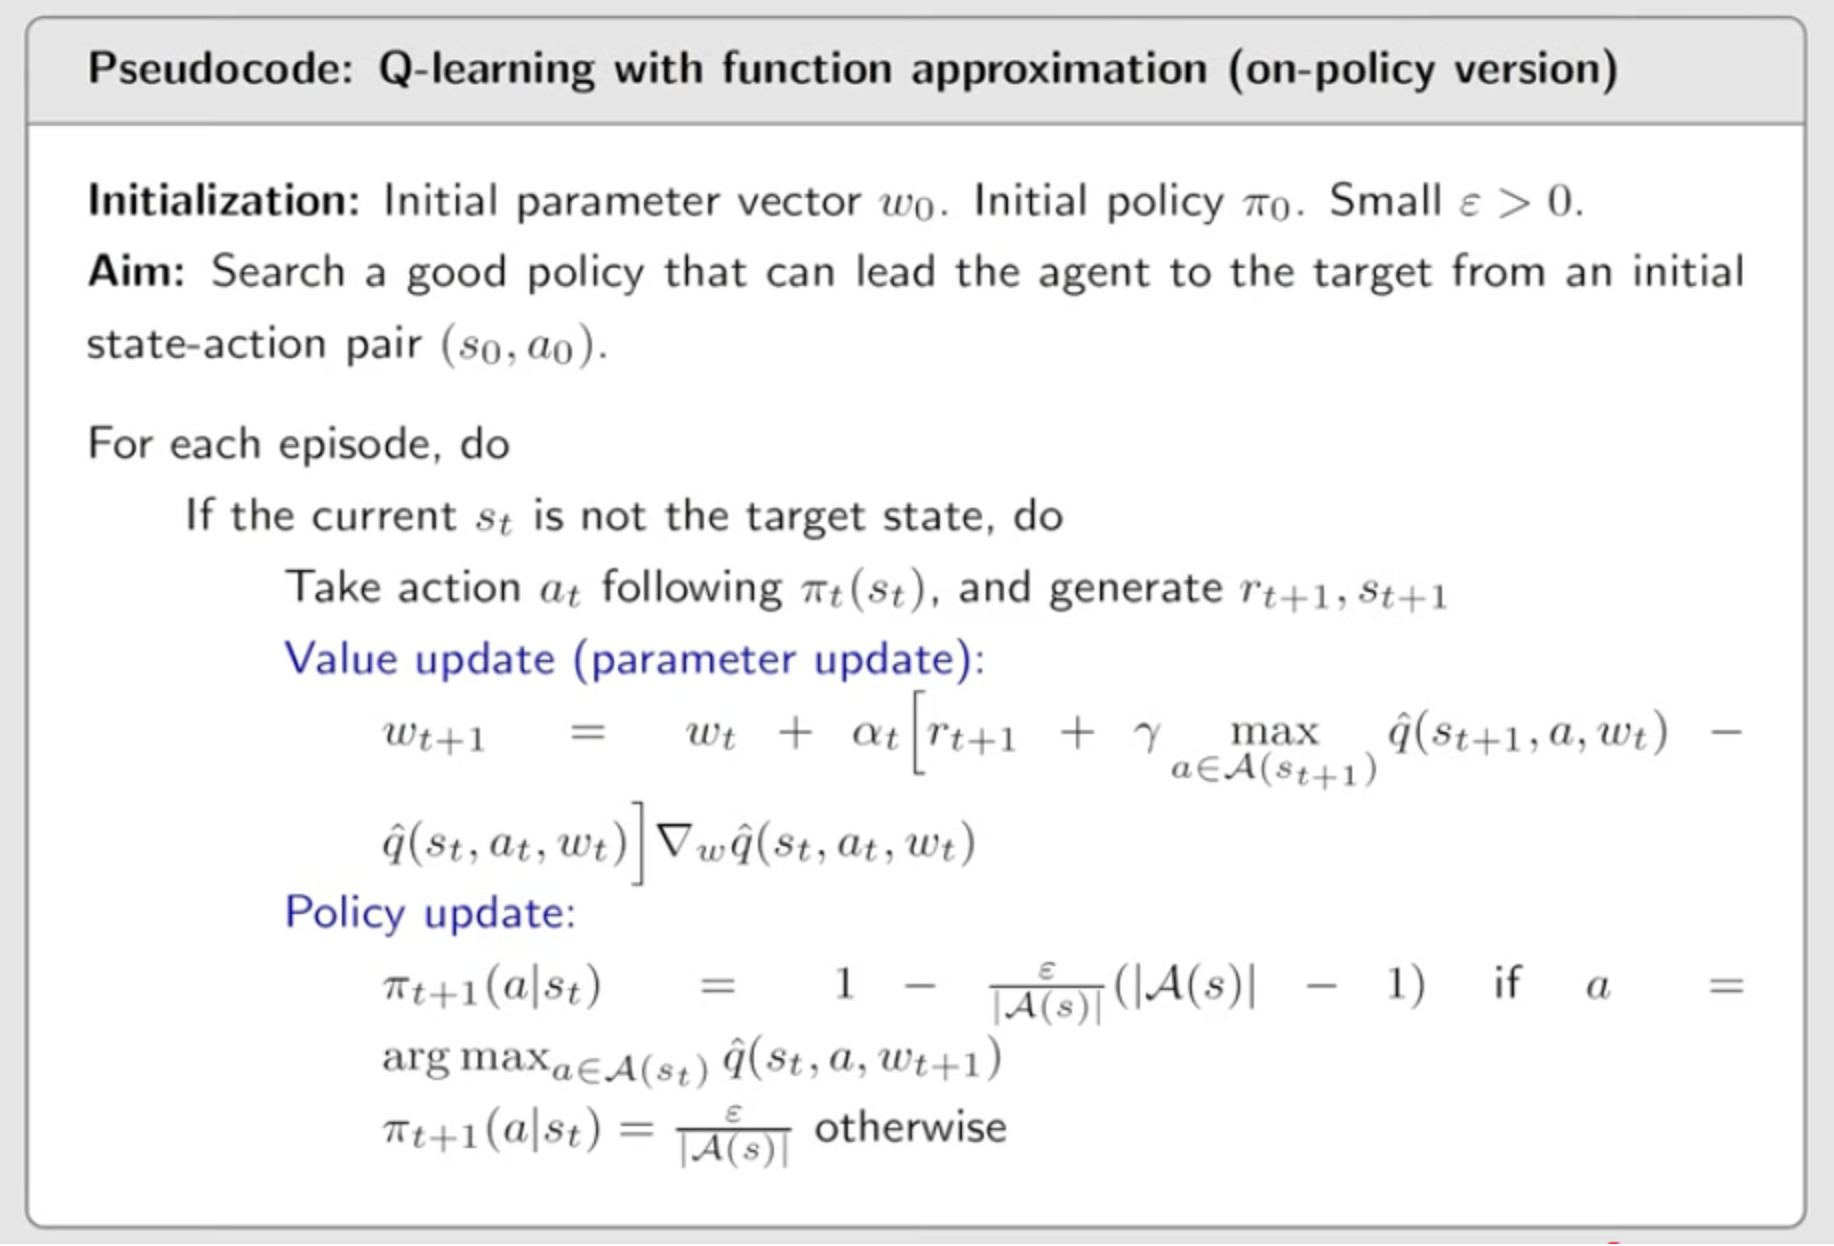

In [ ]:
We can represent the value function $\hat{q}(s_t, a_t, w_t)$ as a linear combination of the state feature $s_t$,
   $$\hat{q}(s_t, a_t, w_t) = X(s_t, a_t)^T . W_t$$
   In general,
      $$\hat{q}(s, a, w) = X^T . W$$
      
So the derivative of $\hat(q)$ w.r.t $W$ is
$$ \triangledown_wq = \frac{d (X^T . W)}{dW}$$
$$ \triangledown_wq = X^T . \frac{dW}{dW}$$
$$ \triangledown_wq = X$$

In [ ]:
import random

In [ ]:
def get_approx_Qsa(W, state, action, env):
    phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector

    Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
    return Q_s_a

def get_max_Q_s(W, state, env):
    Q_s = []
    for action in env.all_action_idx:
        phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
        Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
        Q_s.append(Q_s_a)
    return max(Q_s)

def get_Q_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int16)
    for s in states:
        for a in env.all_action_idx:
            Q[s.idx][a] = get_approx_Qsa(W, s, a, env)
    return Q



In [ ]:
def epsilon_greedy_policy(W, state, env, epsilon=0.2):
    actions = env.all_action_idx    
    if random.random() < epsilon:
        return random.choice(actions) # <---- exploration
    else:
        action_values = []
        for a in actions:
            Q_s_a = get_approx_Qsa(W, state, a, env)
            action_values.append(Q_s_a)
        return actions[np.argmax(action_values)] # <-- exploitation

In [ ]:
def get_policy_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int16)
    for s in states:
        greedy_action = epsilon_greedy_policy(W, s, env, epsilon=0.0) # epsilon=0.0 -> greedy policy
        policy[s.idx] = greedy_action
    return policy

In [ ]:
def run_episode(env, W, state, action, episode_idx, epsilon=0.2, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    trajectory = []
    while True:
        trajectory.append(state.coord)
        
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"] # True if hole or goal ?

        next_action = epsilon_greedy_policy(W,
                                            next_state,
                                            env,
                                            epsilon=1.0) # epsilon = 1 -> off-policy

        # --- update W ---------------------
        # ----------------------------------
        encoded_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
        
        next_max_q_s = get_max_Q_s(W,
                              next_state,
                              env)
        
        q_s_a = get_approx_Qsa(W,
                      state,
                      action,
                      env)
        
        W += alpha * (reward + gamma*next_max_q_s - q_s_a)*encoded_s_a
        # ----------------------------------
        # ----------------------------------

        prev_state = state
        state = next_state
        action = next_action
        
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {state.coord}")
        elif verbose == 2:
            policy = get_policy_table(W, env)
            env.render(policy, next_state, episode_idx, step, reward)
            
        if is_terminated:
            break
        step += 1
    trajectory.append(state.coord)
    return W, get_policy_table(W, env), trajectory

In [ ]:
def run_q_learning_with_fa(env, n_episodes=500, epsilon=0.2, alpha=0.2, gamma=0.2, verbose=0):
    policy_history = []
    W_history = []

    n_features = env.n_states * env.n_actions
    W = np.zeros(n_features)

    trajectory_history = []
    for episode_idx in range(n_episodes):
        initial_state = env.find('S')
        initial_action = 2 #randomly picked

        W, greedy_policy, trajectory = run_episode(env,
                                                    W, 
                                                   initial_state, 
                                                   initial_action, 
                                                   episode_idx,
                                                   epsilon=epsilon,
                                                   alpha=alpha,
                                                   gamma=gamma,
                                                   verbose=verbose)
        trajectory_history.append(trajectory)
        policy_history.append(greedy_policy)
        W_history.append(W)
    return W, policy_history, W_history, trajectory_history

In [ ]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [ ]:
W, policy_history, W_history, trajectory_history = run_q_learning_with_fa(frozen_lake,
                                                      n_episodes=500,
                                                      epsilon=0.2,
                                                      verbose=0)

In [ ]:
policy = policy_history[-1] 

In [ ]:
policy

In [ ]:
W

In [ ]:
Q = get_Q_table(W, frozen_lake)
Q

In [ ]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [ ]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

In [ ]:
# Render policy

In [ ]:
import pandas as pd
from IPython.display import display

In [ ]:
render_policy_and_value(frozen_lake, policy, None)

In [ ]:
plot_trajectory_history(frozen_lake,trajectory_history, policy)

In [ ]:
## Animate Policy history

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:])
HTML(ani.to_jshtml())

In [ ]:
# Play with different grid setup

In [ ]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

In [ ]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [ ]:
Q, policy_history, Q_history, traj_history = run_q_learning_with_fa(frozen_lake, n_episodes=5000, verbose=0)

In [ ]:
policy = policy_history[-1]

In [ ]:
render_policy_and_value(frozen_lake, policy, None)

In [ ]:
plot_trajectory_history(frozen_lake,trajectory_history, policy=None)